# 🖼️ CIFAR-10: ANN vs CNN



##  Step 1 — Imports

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


##  Step 2 — Load & Normalize CIFAR-10

- **50,000** training + **10,000** test images, each **32 × 32 × 3 (RGB)**
- Divide pixels by 255 → values between **0.0 – 1.0** (faster, stable gradients)
- ANN needs a flat vector → reshape 32×32×3 = **3,072 numbers per image**

In [17]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Normalize
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# Flatten for ANN
x_train_flat = x_train_norm.reshape(-1, 3072)
x_test_flat  = x_test_norm.reshape(-1, 3072)

print(f"Train : {x_train.shape}  →  flat: {x_train_flat.shape}")
print(f"Test  : {x_test.shape}   →  flat: {x_test_flat.shape}")

Train : (50000, 32, 32, 3)  →  flat: (50000, 3072)
Test  : (10000, 32, 32, 3)   →  flat: (10000, 3072)


##  Step 3 — Peek at Sample Images

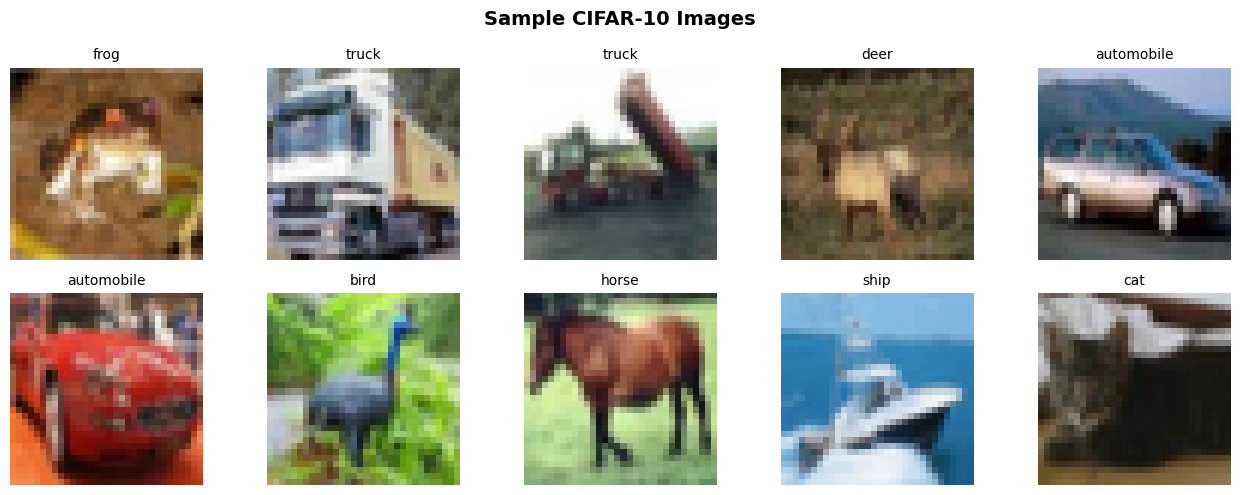

In [18]:
plt.figure(figsize=(13, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(CLASS_NAMES[y_train[i][0]], fontsize=10)
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔹 Baseline — ANN Model

ANN **flattens** the image into a list of 3,072 numbers.  


| Layer | Size | Purpose |
|-------|------|---------|
| Dense | 512 | Learn broad patterns |
| Dropout | 0.3 | Reduce overfitting |
| Dense | 256 | Refine features |
| Dense | 10 | Classify into 10 classes |

In [19]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Baseline')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

ann_loss, ann_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\n✅ ANN Baseline  →  Test Accuracy: {ann_acc:.4f}  ({ann_acc*100:.1f}%)")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2741 - loss: 1.9856 - val_accuracy: 0.3394 - val_loss: 1.8566
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3174 - loss: 1.8711 - val_accuracy: 0.3554 - val_loss: 1.7935
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3362 - loss: 1.8240 - val_accuracy: 0.3728 - val_loss: 1.7737
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3484 - loss: 1.7847 - val_accuracy: 0.3534 - val_loss: 1.7793
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3608 - loss: 1.7624 - val_accuracy: 0.3932 - val_loss: 1.7266
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3667 - loss: 1.7383 - val_accuracy: 0.3940 - val_loss: 1.7031
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3747 - loss: 1.7260 - val_accuracy: 0.4120 - val_loss: 1.6644
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3876 - loss: 1.6961 - val_accuracy: 0.

---
## 🔹 Baseline — CNN Model

CNN slides a small **filter window** across the image:  
`Conv2D` → detects edges / textures | `MaxPooling2D` → keeps strongest signals | `BatchNorm` → stabilises training

| Block | Filters | Spatial size after pool |
|-------|---------|------------------------|
| Block 1 | 32 | 32×32 → 16×16 |
| Block 2 | 64 | 16×16 → 8×8 |
| Block 3 | 128 | 8×8 (no pool) |

In [21]:
cnn_model = models.Sequential([

    # Block 1 — 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Classification head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')

], name='CNN_Baseline')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n CNN Baseline Test Accuracy: {cnn_acc:.4f}  ({cnn_acc*100:.1f}%)")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4118 - loss: 1.6390 - val_accuracy: 0.4988 - val_loss: 1.3958
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5673 - loss: 1.2217 - val_accuracy: 0.6138 - val_loss: 1.0860
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6548 - loss: 0.9914 - val_accuracy: 0.6514 - val_loss: 1.0151
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7038 - loss: 0.8484 - val_accuracy: 0.6948 - val_loss: 0.9047
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7419 - loss: 0.7383 - val_accuracy: 0.7394 - val_loss: 0.7918
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7748 - loss: 0.6372 - val_accuracy: 0.7210 - val_loss: 0.8112
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8036 - loss: 0.5561 - val_accuracy: 0.7300 - val_loss: 0.8824
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8276 - loss: 0.4872 - val_accuracy: 

---
## Validation Accuracy Curve: ANN vs CNN (10 Epochs)

Both models trained for **exactly 10 epochs** ,
so the chart x-axis is a clean 1 → 10 comparison.

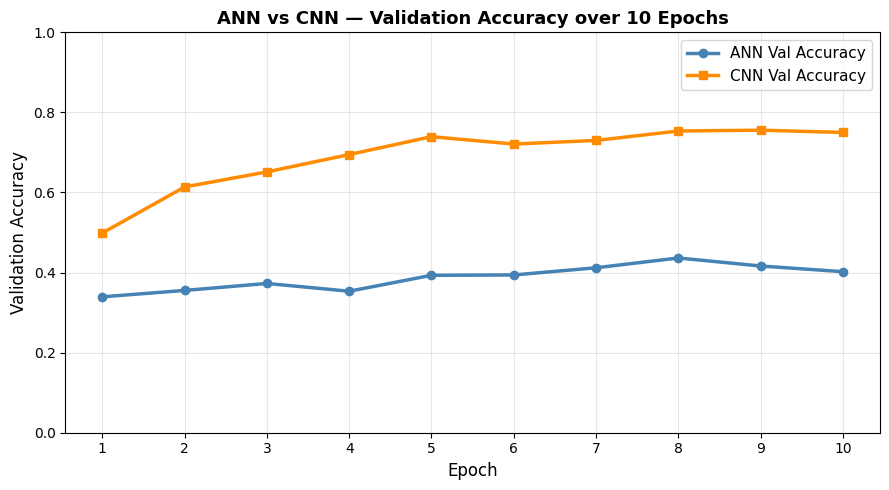

  ANN final val accuracy  : 0.4022
  CNN final val accuracy  : 0.7500


In [23]:
epochs_x = range(1, 11)

plt.figure(figsize=(9, 5))
plt.plot(epochs_x, ann_history.history['val_accuracy'],
         label='ANN Val Accuracy', marker='o', linewidth=2.5, color='steelblue')
plt.plot(epochs_x, cnn_history.history['val_accuracy'],
         label='CNN Val Accuracy', marker='s', linewidth=2.5, color='darkorange')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('ANN vs CNN — Validation Accuracy over 10 Epochs',
          fontsize=13, fontweight='bold')
plt.xticks(epochs_x)
plt.ylim(0, 1)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"  ANN final val accuracy  : {ann_history.history['val_accuracy'][-1]:.4f}")
print(f"  CNN final val accuracy  : {cnn_history.history['val_accuracy'][-1]:.4f}")

---
## Final Comparison DataFrame: ANN vs CNN Test Accuracy

In [24]:
baseline_df = pd.DataFrame({
    'Model'             : ['ANN', 'CNN'],
    'Architecture'      : ['Dense 512 → 256 → 10',
                           'Conv 32 → 64 → 128 + Dense 128 → 10'],
    'Epochs Trained'    : [10, 10],
    'Test Accuracy (%)' : [round(ann_acc * 100, 2), round(cnn_acc * 100, 2)],
    'Test Loss'         : [round(ann_loss, 4),       round(cnn_loss, 4)],
})

display(baseline_df)

diff = cnn_acc - ann_acc
print(f"\nCNN outperforms ANN by {diff*100:.1f} percentage points")

,Model,Architecture,Epochs Trained,Test Accuracy (%),Test Loss
0,ANN,Dense 512 → 256 → 10,10,40.62,1.6556
1,CNN,Conv 32 → 64 → 128 + Dense 128 → 10,10,72.73,0.9682



CNN outperforms ANN by 32.1 percentage points


---
---
# Student Learning Tasks
### Five tasks that build on the baseline results above

| Task | Goal |
|------|------|
| **Task 1** | Increase ANN dense layers |
| **Task 2** | Confirm CNN filter scale: 32 → 64 → 128 |
| **Task 3** | Increase training to 20 epochs |
| **Task 4** | Add EarlyStopping |
| **Task 5** | Execute the data-augmented training run |

### Task 1 — Increase ANN Dense Layers
Add two more hidden layers: 512 → 256 → **128 → 64** → 10

In [25]:
ann_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),   #  new layer
    layers.Dense(64,  activation='relu'),   #  new layer
    layers.Dense(10,  activation='softmax')
], name='ANN_Deep_Task1')

ann_deep.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("ANN now has 4 hidden layers")
ann_deep.summary()

ANN now has 4 hidden layers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Deep_Task1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,506 (6.66 MB)

 Trainable params: 1,746,506 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

### Task 2 — CNN Filter Scale: 32 → 64 → 128
The baseline CNN was already built with this exact progression.

In [26]:
print("CNN filter sizes confirmed:")
print(f"  {'Layer':<30} {'Filters'}")
for layer in cnn_model.layers:
    if hasattr(layer, 'filters'):
        print(f"  {layer.name:<30} {layer.filters}")

CNN filter sizes confirmed:
  Layer                          Filters
  conv2d_9                       32
  conv2d_10                      64
  conv2d_11                      128


###Task 3 — Increase Training to 20 Epochs
Re-train the deeper ANN for 20 epochs instead of 10:

In [27]:
print("Training ANN Deep for 20 epochs")

ann_deep_history = ann_deep.fit(
    x_train_flat, y_train,
    epochs=20,              # 20 epochs
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

ann_deep_loss, ann_deep_acc = ann_deep.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nANN Deep (20 epochs)  Test Accuracy: {ann_deep_acc:.4f}  ({ann_deep_acc*100:.1f}%)")

Training ANN Deep for 20 epochs
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2464 - loss: 2.0279 - val_accuracy: 0.3048 - val_loss: 1.8895
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2996 - loss: 1.9024 - val_accuracy: 0.3340 - val_loss: 1.8270
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3221 - loss: 1.8454 - val_accuracy: 0.3594 - val_loss: 1.8062
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3308 - loss: 1.8265 - val_accuracy: 0.3706 - val_loss: 1.7774
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3461 - loss: 1.7899 - val_accuracy: 0.4010 - val_loss: 1.7374
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3554 - loss: 1.7683 - val_accuracy: 0.3964 - val_loss: 1.7225
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3651 - loss: 1.7491 - val_accuracy: 0.3844 - val_loss: 1.7186
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3680 -

###Task 4 — Add EarlyStopping
EarlyStopping watches `val_loss`. If it doesn't improve for **3 consecutive epochs**,
training stops automatically and the best weights are restored.

In [28]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Rebuild CNN with EarlyStopping + 20 epoch cap
cnn_es = models.Sequential([
    layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_EarlyStopping_Task4')

cnn_es.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

print("Training CNN with EarlyStopping (up to 20 epochs)")
cnn_es_history = cnn_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],    # EarlyStopping active
    verbose=1
)

cnn_es_loss, cnn_es_acc = cnn_es.evaluate(x_test_norm, y_test, verbose=0)
actual_epochs = len(cnn_es_history.history['val_loss'])
print(f"\nCNN + EarlyStopping    Stopped at epoch {actual_epochs}")
print(f"Test Accuracy: {cnn_es_acc:.4f}  ({cnn_es_acc*100:.1f}%)")

Training CNN with EarlyStopping (up to 20 epochs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4270 - loss: 1.6005 - val_accuracy: 0.5078 - val_loss: 1.3782
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5844 - loss: 1.1768 - val_accuracy: 0.5726 - val_loss: 1.3004
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6586 - loss: 0.9682 - val_accuracy: 0.6528 - val_loss: 0.9790
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7041 - loss: 0.8394 - val_accuracy: 0.6984 - val_loss: 0.8866
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7432 - loss: 0.7309 - val_accuracy: 0.7192 - val_loss: 0.8058
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7742 - loss: 0.6435 - val_accuracy: 0.7068 - val_loss: 0.8855
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8018 - loss: 0.5615 - val_accuracy: 0.7048 - val_loss: 0.9649
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8244 - loss: 0.4947 - val_accuracy: 

###Task 5 — Data Augmentation Training Run
Augmentation generates transformed copies of training images on the fly:

The model sees more visual variety → generalises better to unseen images.

In [29]:
augment_pipeline = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='Augmentation')

aug_cnn = models.Sequential([
    augment_pipeline,
    layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Augmented_CNN_Task5')

aug_cnn.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

print("Training Augmented CNN (up to 20 epochs + EarlyStopping)")
aug_history = aug_cnn.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

aug_loss, aug_acc = aug_cnn.evaluate(x_test_norm, y_test, verbose=0)
aug_epochs = len(aug_history.history['val_loss'])
print(f"\nAugmented CNN  →  Stopped at epoch {aug_epochs}")
print(f"Test Accuracy: {aug_acc:.4f}  ({aug_acc*100:.1f}%)")

Training Augmented CNN (up to 20 epochs + EarlyStopping)
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.3540 - loss: 1.7796 - val_accuracy: 0.4554 - val_loss: 1.5126
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4695 - loss: 1.4754 - val_accuracy: 0.5330 - val_loss: 1.3054
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5246 - loss: 1.3387 - val_accuracy: 0.5866 - val_loss: 1.1716
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

Augmented CNN  →  Stopped at epoch 3
Test Accuracy: 0.4616  (46.2%)


---
##All-Model Comparison

In [30]:
full_df = pd.DataFrame({
    'Model': [
        'ANN Baseline',
        'ANN Deep',
        'CNN Baseline',
        'CNN + EarlyStopping',
        'Augmented CNN'
    ],
    'Test Accuracy (%)': [
        round(ann_acc      * 100, 2),
        round(ann_deep_acc * 100, 2),
        round(cnn_acc      * 100, 2),
        round(cnn_es_acc   * 100, 2),
        round(aug_acc      * 100, 2),
    ],
    'Epochs Run': [
        10,
        len(ann_deep_history.history['val_loss']),
        10,
        len(cnn_es_history.history['val_loss']),
        len(aug_history.history['val_loss']),
    ],
    'EarlyStopping': ['No','No','No','Yes','Yes'],
    'Augmentation' : ['No','No','No','No', 'Yes'],
})

print("FULL MODEL COMPARISON")
display(full_df)

best_idx = full_df['Test Accuracy (%)'].idxmax()
print(f"\nBest model: {full_df.loc[best_idx, 'Model']}  "
      f"({full_df.loc[best_idx, 'Test Accuracy (%)']}%)")

FULL MODEL COMPARISON


,Model,Test Accuracy (%),Epochs Run,EarlyStopping,Augmentation
0,ANN Baseline,40.62,10,No,No
1,ANN Deep,43.28,20,No,No
2,CNN Baseline,72.73,10,No,No
3,CNN + EarlyStopping,70.56,8,Yes,No
4,Augmented CNN,46.16,3,Yes,Yes



Best model: CNN Baseline  (72.73%)


---
## Key Takeaways

| Concept | Insight |
|---------|---------|
| **ANN** | Loses spatial structure → ~50% accuracy |
| **Deeper ANN** | More layers help slightly, but ceiling is low |
| **CNN** | Preserves spatial patterns → ~70–76% accuracy |
| **EarlyStopping** | Prevents wasted epochs and overfitting automatically |
| **Augmentation** | Improves generalisation, especially on small datasets |

